# 03 — Homología persistente (Vietoris-Rips)

Para cada nivel educativo construimos el complejo de Vietoris-Rips sobre las
coordenadas UTM (en metros) y calculamos los diagramas de persistencia H0/H1.
Las features H1 persistentes corresponden a **huecos de cobertura escolar**:
regiones cerradas por escuelas alrededor pero sin escuelas dentro.


In [1]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from ripser import ripser
from persim import plot_diagrams
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TDA_DIR = ROOT / 'data' / 'processed' / 'tda_results'
TDA_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(ROOT / 'data' / 'processed' / 'escuelas_cdmx.parquet')
print(len(df), 'escuelas; niveles:', df['nivel'].unique())


5587 escuelas; niveles: ['primaria' 'preescolar' 'secundaria' 'media_tecnica' 'media_superior']


In [2]:
def landmark_sample(X: np.ndarray, max_n: int = 1500, seed: int = 0) -> np.ndarray:
    '''Si X es muy grande, submuestrear con KMeans (preserva geometría).'''
    if len(X) <= max_n:
        return X
    km = KMeans(n_clusters=max_n, n_init=3, random_state=seed).fit(X)
    return km.cluster_centers_

THRESH = 3000.0  # metros — radio de caminata interpretable
MAX_N = 1500     # punto de corte para subsampling


In [3]:
def compute_tda(X_metros: np.ndarray, thresh: float = THRESH):
    Xs = landmark_sample(X_metros, MAX_N)
    res = ripser(Xs, maxdim=1, thresh=thresh, do_cocycles=True)
    return {
        'X': Xs,
        'X_original_n': len(X_metros),
        'dgms': res['dgms'],
        'cocycles': res['cocycles'],
        'thresh': thresh,
    }

# Calcular por nivel
results = {}
for nivel, g in df.groupby('nivel'):
    X = g[['x_utm','y_utm']].values
    print(f'computando {nivel}: {len(X)} pts ...', end=' ')
    results[nivel] = compute_tda(X)
    print('listo')

# Y para todas las escuelas juntas
results['todas'] = compute_tda(df[['x_utm','y_utm']].values)
print('todas:', results['todas']['X_original_n'], 'pts')


computando media_superior: 325 pts ... listo
computando media_tecnica: 36 pts ... listo
computando preescolar: 2254 pts ... listo
computando primaria: 2275 pts ... listo
computando secundaria: 697 pts ... listo
todas: 5587 pts


In [4]:
# Guardar para que el dashboard cargue rápido
for name, r in results.items():
    with open(TDA_DIR / f'{name}.pkl', 'wb') as f:
        pickle.dump(r, f)
print('guardados:', sorted(TDA_DIR.glob('*.pkl')))


guardados: [WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/media_superior.pkl'), WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/media_tecnica.pkl'), WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/preescolar.pkl'), WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/primaria.pkl'), WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/secundaria.pkl'), WindowsPath('c:/Users/eduar/Documents/Universidad/Proyecto Hugo/data/processed/tda_results/todas.pkl')]


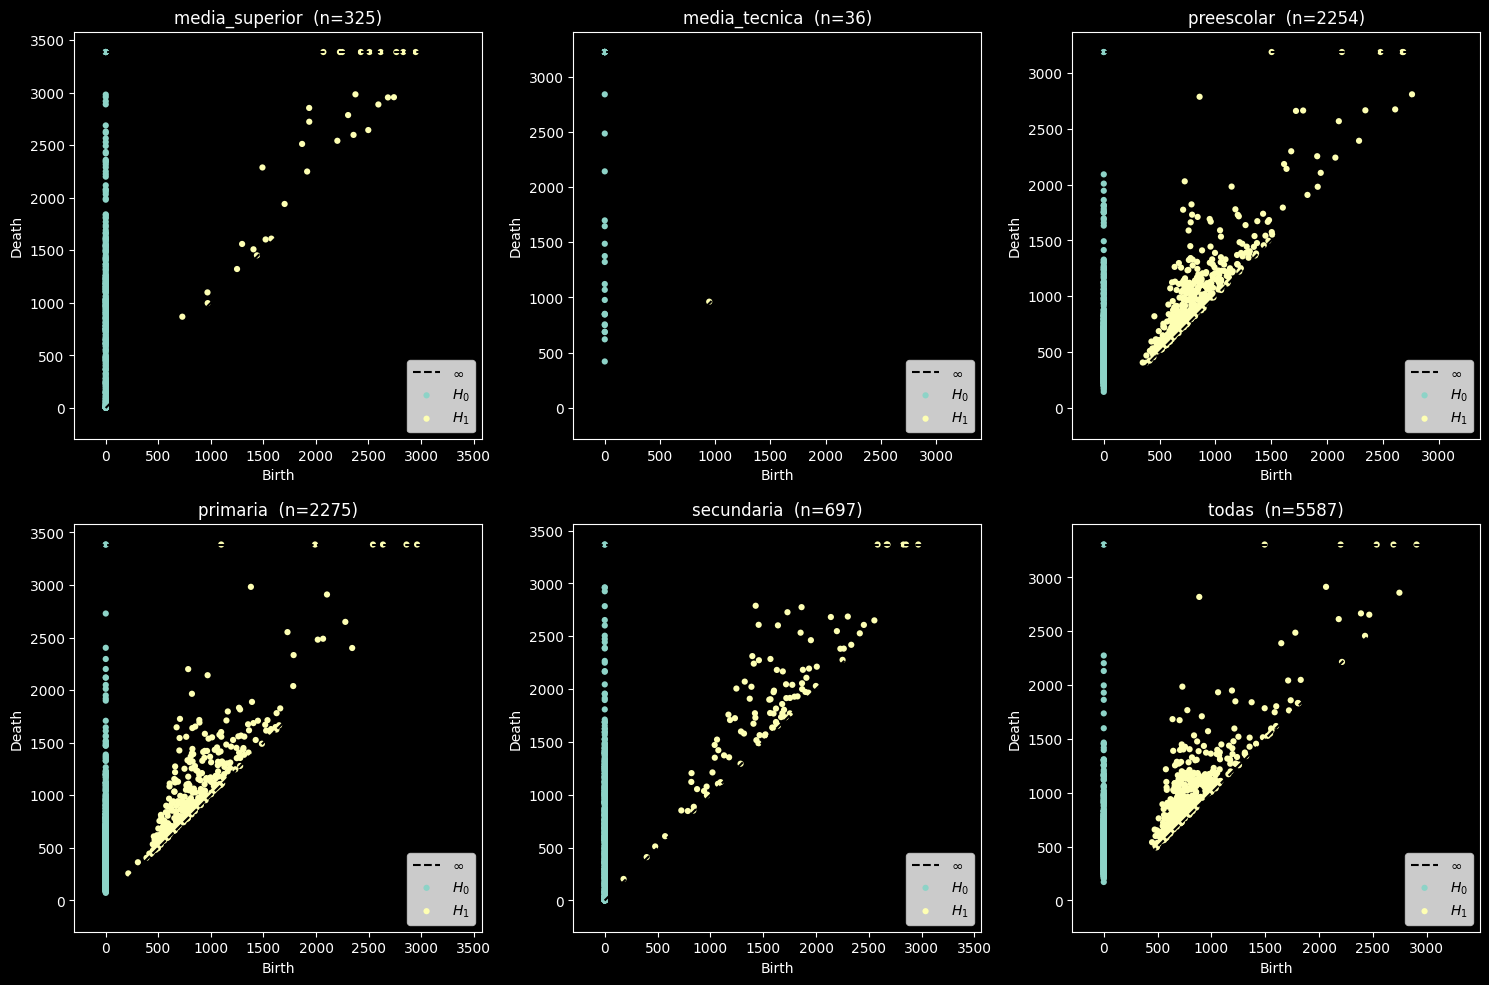

In [5]:
# Diagramas de persistencia por nivel
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, r) in zip(axes.flat, results.items()):
    plot_diagrams(r['dgms'], show=False, ax=ax)
    ax.set_title(f'{name}  (n={r["X_original_n"]})')
plt.tight_layout()
plt.show()


In [6]:
# Top features H1 (huecos persistentes) por nivel
def top_h1(r, k=5):
    h1 = r['dgms'][1]
    if len(h1) == 0:
        return np.empty((0, 3))
    pers = h1[:, 1] - h1[:, 0]
    idx = np.argsort(-pers)[:k]
    return np.column_stack([h1[idx], pers[idx]])

for name in ['preescolar','primaria','secundaria','media_superior','media_tecnica','todas']:
    if name not in results: continue
    arr = top_h1(results[name], 5)
    print(f'\n{name}: top-5 H1 (birth, death, persistencia en metros)')
    if len(arr):
        for b, d, p in arr:
            print(f'  ε∈[{b:7.1f}, {d:7.1f}]  persistencia={p:7.1f} m')
    else:
        print('  (sin features H1)')



preescolar: top-5 H1 (birth, death, persistencia en metros)
  ε∈[ 1503.8,     inf]  persistencia=    inf m
  ε∈[ 2683.2,     inf]  persistencia=    inf m
  ε∈[ 2132.8,     inf]  persistencia=    inf m
  ε∈[ 2675.3,     inf]  persistencia=    inf m
  ε∈[ 2478.7,     inf]  persistencia=    inf m

primaria: top-5 H1 (birth, death, persistencia en metros)
  ε∈[ 2961.1,     inf]  persistencia=    inf m
  ε∈[ 2860.7,     inf]  persistencia=    inf m
  ε∈[ 2636.8,     inf]  persistencia=    inf m
  ε∈[ 2541.7,     inf]  persistencia=    inf m
  ε∈[ 1990.5,     inf]  persistencia=    inf m

secundaria: top-5 H1 (birth, death, persistencia en metros)
  ε∈[ 2968.2,     inf]  persistencia=    inf m
  ε∈[ 2851.9,     inf]  persistencia=    inf m
  ε∈[ 2827.0,     inf]  persistencia=    inf m
  ε∈[ 2676.4,     inf]  persistencia=    inf m
  ε∈[ 2669.6,     inf]  persistencia=    inf m

media_superior: top-5 H1 (birth, death, persistencia en metros)
  ε∈[ 2949.2,     inf]  persistencia=    inf m
  

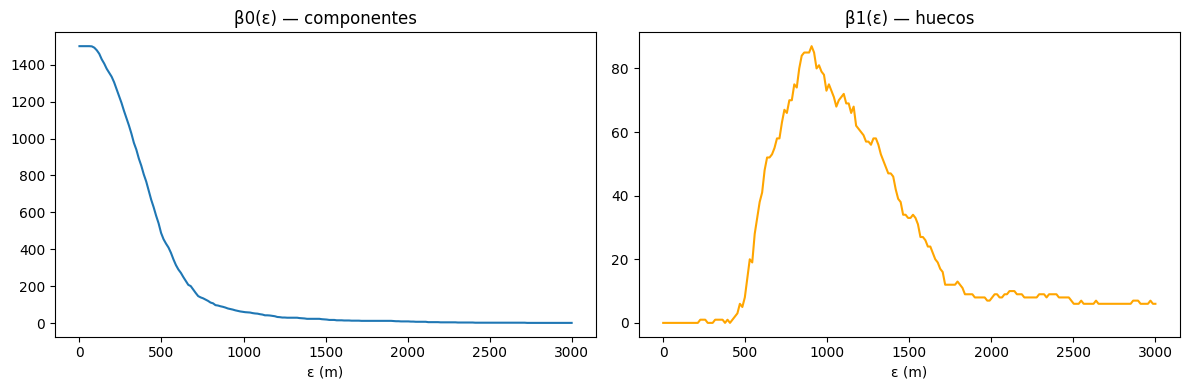

In [7]:
# Curvas de Betti β0(ε) y β1(ε) para 'primaria'
def betti_curves(dgms, eps_range):
    betti = []
    for eps in eps_range:
        b0 = np.sum((dgms[0][:,0] <= eps) & (dgms[0][:,1] > eps))
        b1 = np.sum((dgms[1][:,0] <= eps) & (dgms[1][:,1] > eps))
        betti.append((b0, b1))
    return np.array(betti)

eps = np.linspace(0, THRESH, 200)
bc = betti_curves(results['primaria']['dgms'], eps)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(eps, bc[:,0]); ax[0].set_title('β0(ε) — componentes'); ax[0].set_xlabel('ε (m)')
ax[1].plot(eps, bc[:,1], color='orange'); ax[1].set_title('β1(ε) — huecos'); ax[1].set_xlabel('ε (m)')
plt.tight_layout(); plt.show()


## Interpretación

- **β0(ε)** decrece hasta llegar a 1 cuando el grafo se vuelve conexo: la
  ε en que esto ocurre estima cuánto hay que caminar entre escuelas vecinas.
- **β1(ε)** alcanza un pico y luego decae: ese pico nos dice **cuántos huecos
  simultáneos** persisten en la red de cobertura escolar.
- Las features H1 con mayor persistencia son las zonas más significativas
  sin escuelas — se exploran geográficamente en el notebook 04.
